In [1]:
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 135.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 4.3 MB/s eta 0:00:00


In [2]:


from roboflow import Roboflow
rf = Roboflow(api_key="fg4aUhwvwxfe7SWv6bk3")
project = rf.workspace("sj-ytwh0").project("cdd_eggs_sj")
version = project.version(2)
dataset = version.download("folder")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to CDD_eggs_SJ-2 in folder:: 100%|██████████| 9551/9551 [00:00<00:00, 10019.94it/s]


In [ ]:
import os

print("Contenido de /content:")
print(os.listdir("/content"))

Contenido de /content:
['.config', 'CDD_eggs_SJ-2', 'sample_data']


In [ ]:


for root, dirs, files in os.walk("/content"):
    level = root.replace("/content", "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    
    if level >= 2:
        dirs[:] = []

content/
    .config/
        configurations/
        logs/
    CDD_eggs_SJ-2/
        train/
        test/
        valid/
    sample_data/


In [5]:
from pathlib import Path

extensiones = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

imagenes = []

for archivo in Path("/content").rglob("*"):
    if archivo.is_file() and archivo.suffix.lower() in extensiones:
        imagenes.append(archivo)

print(f"Total de imágenes encontradas: {len(imagenes)}")

Total de imágenes encontradas: 9549


In [ ]:
from collections import Counter

conteo_clases = Counter()

for imagen in imagenes:
    partes = imagen.parts
    
    for clase in ["broken", "dirty", "good"]:
        if clase in partes:
            conteo_clases[clase] += 1
            break

print("Cantidad de imágenes por clase:")
print()

for clase, cantidad in conteo_clases.items():
    print(f"{clase}: {cantidad}")

Cantidad de imágenes por clase:

broken: 3649
good: 2953
dirty: 2947


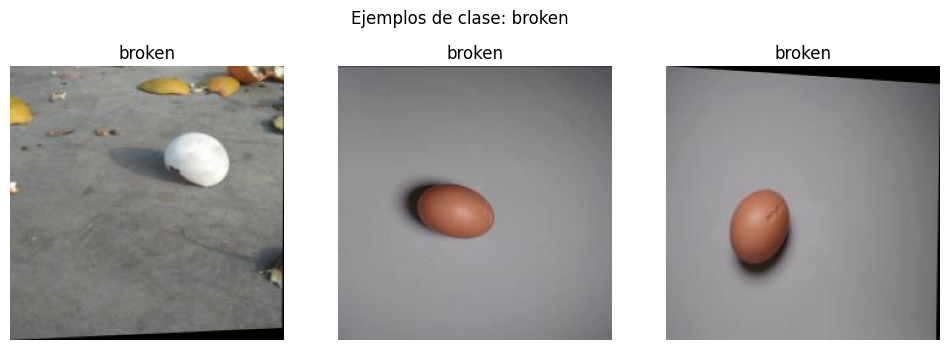

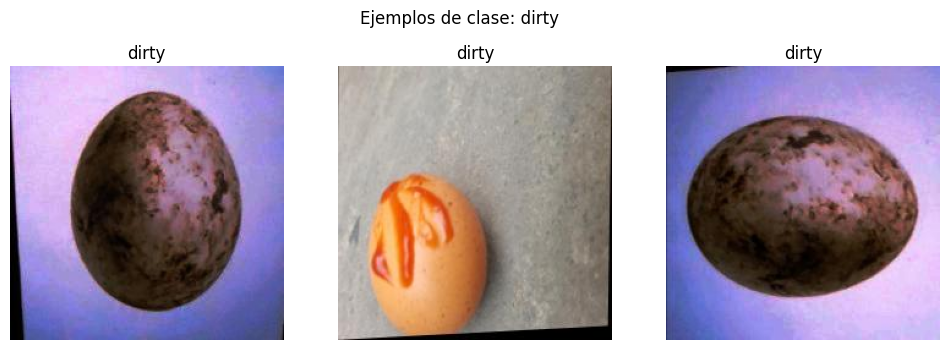

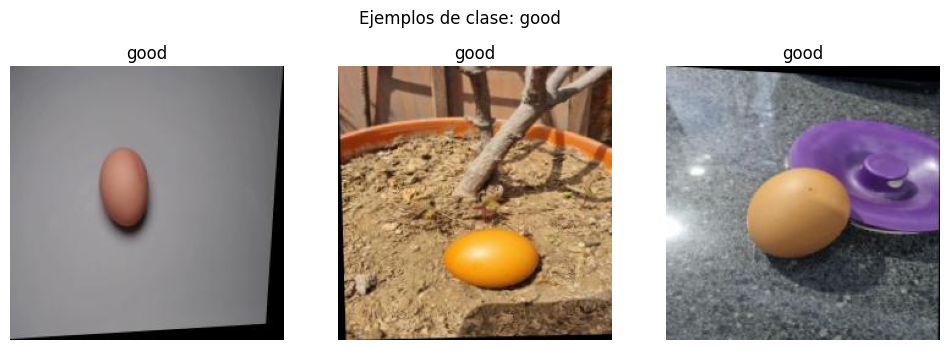

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import random

for clase in ["broken", "dirty", "good"]:
    
    imagenes_clase = [
        img for img in imagenes
        if clase in img.parts
    ]
    
    muestras = random.sample(
        imagenes_clase,
        min(3, len(imagenes_clase))
    )
    
    plt.figure(figsize=(12, 4))
    
    for i, ruta in enumerate(muestras):
        imagen = Image.open(ruta)
        
        plt.subplot(1, len(muestras), i + 1)
        plt.imshow(imagen)
        plt.title(clase)
        plt.axis("off")
    
    plt.suptitle(f"Ejemplos de clase: {clase}")
    plt.show()

In [8]:
from collections import Counter
from PIL import Image

tamanos = Counter()

for ruta in imagenes:
    try:
        with Image.open(ruta) as img:
            tamanos[img.size] += 1
    except Exception as e:
        print(f"Error leyendo {ruta}: {e}")

print("Resoluciones encontradas:")
for tamano, cantidad in tamanos.most_common(20):
    print(f"{tamano}: {cantidad} imágenes")

Resoluciones encontradas:
(224, 224): 9549 imágenes


In [9]:
from PIL import Image

corruptas = []

for ruta in imagenes:
    try:
        with Image.open(ruta) as img:
            img.verify()
    except Exception:
        corruptas.append(ruta)

print(f"Imágenes corruptas: {len(corruptas)}")

if corruptas:
    print("\nArchivos problemáticos:")
    for ruta in corruptas[:20]:
        print(ruta)

Imágenes corruptas: 0


In [10]:
from pathlib import Path
from collections import Counter

dataset_path = Path("/content/CDD_eggs_SJ-2")

splits = ["train", "valid", "test"]
classes = ["broken", "dirty", "good"]

print("DISTRIBUCIÓN DEL DATASET")
print("=" * 50)

total_general = 0

for split in splits:

    print(f"\n{split.upper()}")
    print("-" * 30)

    total_split = 0

    for clase in classes:

        carpeta = dataset_path / split / clase

        if carpeta.exists():
            cantidad = len([
                archivo for archivo in carpeta.iterdir()
                if archivo.is_file()
            ])
        else:
            cantidad = 0

        print(f"{clase:10}: {cantidad}")

        total_split += cantidad

    print(f"TOTAL      : {total_split}")

    total_general += total_split

print("\n" + "=" * 50)
print(f"TOTAL GENERAL: {total_general}")

DISTRIBUCIÓN DEL DATASET

TRAIN
------------------------------
broken    : 3242
dirty     : 2630
good      : 2616
TOTAL      : 8488

VALID
------------------------------
broken    : 206
dirty     : 159
good      : 166
TOTAL      : 531

TEST
------------------------------
broken    : 201
dirty     : 158
good      : 171
TOTAL      : 530

TOTAL GENERAL: 9549


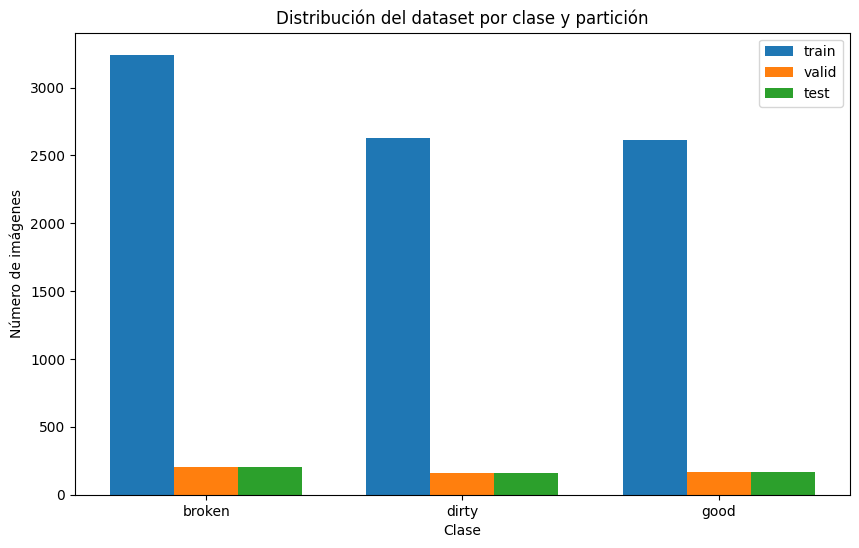

In [11]:
import matplotlib.pyplot as plt

conteos = {}

for split in splits:

    conteos[split] = []

    for clase in classes:

        carpeta = dataset_path / split / clase

        cantidad = len([
            archivo for archivo in carpeta.iterdir()
            if archivo.is_file()
        ])

        conteos[split].append(cantidad)


x = range(len(classes))
ancho = 0.25

plt.figure(figsize=(10, 6))

for i, split in enumerate(splits):
    posiciones = [pos + (i - 1) * ancho for pos in x]

    plt.bar(
        posiciones,
        conteos[split],
        width=ancho,
        label=split
    )

plt.xticks(list(x), classes)
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.title("Distribución del dataset por clase y partición")
plt.legend()
plt.show()

In [ ]:
totales = {}

for split in splits:

    total = sum(conteos[split])
    totales[split] = total

total_dataset = sum(totales.values())

print("DISTRIBUCIÓN POR PARTICIONES")
print("=" * 40)

for split, cantidad in totales.items():

    porcentaje = cantidad / total_dataset * 100

    print(
        f"{split:6}: "
        f"{cantidad:5} imágenes "
        f"({porcentaje:.2f}%)"
    )

DISTRIBUCIÓN POR PARTICIONES
train :  8488 imágenes (88.89%)
valid :   531 imágenes (5.56%)
test  :   530 imágenes (5.55%)


# A partir de este punto se empieza con el modelo

In [13]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "/content/CDD_eggs_SJ-2/train"
valid_dir = "/content/CDD_eggs_SJ-2/valid"
test_dir  = "/content/CDD_eggs_SJ-2/test"

In [14]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 8488 files belonging to 3 classes.


In [15]:
valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 531 files belonging to 3 classes.


In [16]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 530 files belonging to 3 classes.


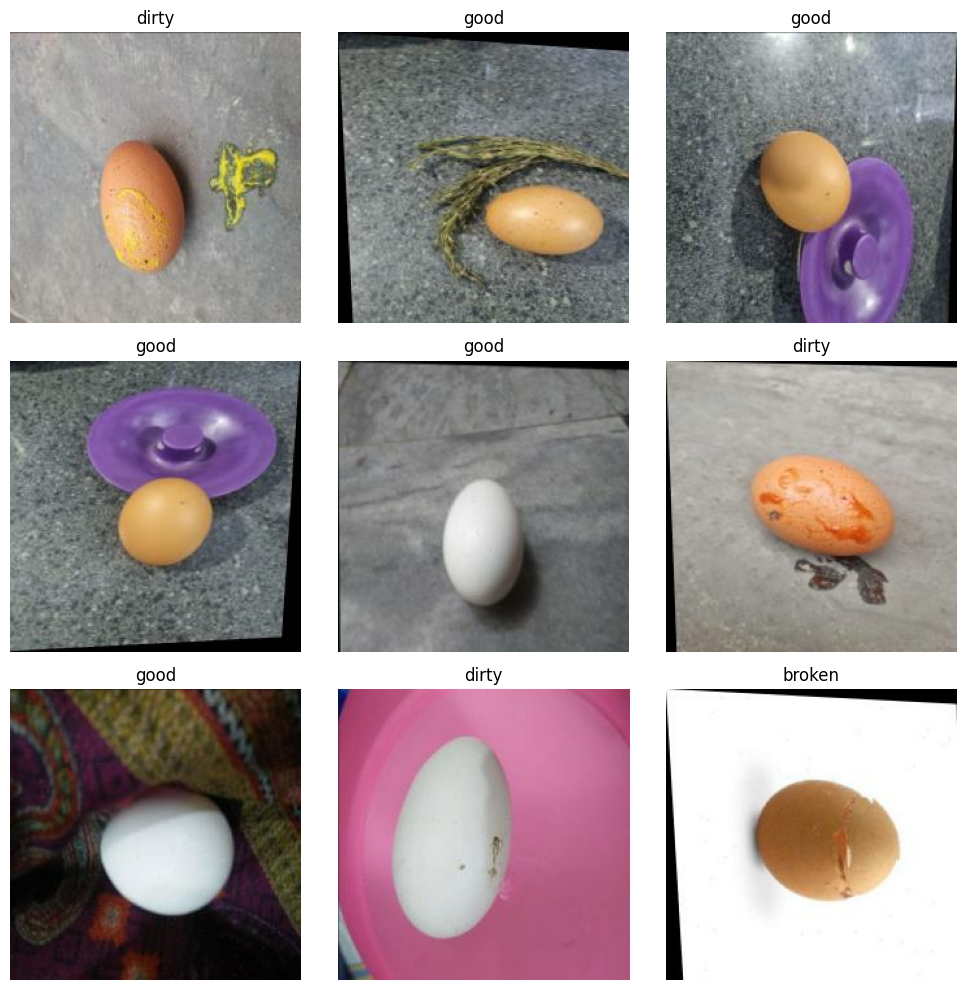

In [17]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        clase = train_ds.class_names[labels[i]]

        plt.title(clase)
        plt.axis("off")

plt.tight_layout()
plt.show()

Nota: El "dirty" no solo llamara la atencion a un huevo que posiblemente pueda estar malo, sino que tambien podria detectar otro tipo de "suciedades" como manchas rojas de embriones

In [18]:
import tensorflow as tf
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 3

print("TensorFlow:", tf.__version__)
print("Clases:", train_ds.class_names)

TensorFlow: 2.20.0
Clases: ['broken', 'dirty', 'good']


In [19]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="data_augmentation")

# EL MODELO

In [20]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [21]:
base_model.trainable = False

#Base preentrenada congelada para seguir con las demas celdas, o capas

Clasificador

In [22]:
inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.20)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam( #ADAM
        learning_rate=1e-4
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

In [24]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
trainable_params = sum(
    tf.keras.backend.count_params(weight)
    for weight in model.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(weight)
    for weight in model.non_trainable_weights
)

print(f"Parámetros entrenables: {trainable_params:,}")
print(f"Parámetros congelados: {non_trainable_params:,}")

Parámetros entrenables: 3,843
Parámetros congelados: 2,257,984


In [26]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5, #Si el modelo no mejora en 5 epocas, se detiene
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_egg_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau( #Para cambiar el 0.001 a otro valor si es que no mejora
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

Primer entrenamiento

In [27]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5206 - loss: 1.0233
Epoch 1: val_loss improved from None to 0.41805, saving model to best_egg_model.keras

Epoch 1: finished saving model to best_egg_model.keras
266/266 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.6647 - loss: 0.7706 - val_accuracy: 0.8493 - val_loss: 0.4181 - learning_rate: 1.0000e-04
Epoch 2/30
265/266 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8345 - loss: 0.4274
Epoch 2: val_loss improved from 0.41805 to 0.29030, saving model to best_egg_model.keras

Epoch 2: finished saving model to best_egg_model.keras
266/266 ━━━━━━━━━━━━━━━━━━━━ 18s 67ms/step - accuracy: 0.8493 - loss: 0.3915 - val_accuracy: 0.8964 - val_loss: 0.2903 - learning_rate: 1.0000e-04
Epoch 3/30
265/266 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8711 - loss: 0.3241
Epoch 3: val_loss improved from 0.29030 to 0.24238, saving model to best_egg_model.keras

Epoch 3: finished saving model to best_egg_model.keras
266/266 ━━━━━

Evaluar el modelo con test

In [28]:
best_model = tf.keras.models.load_model(
    "best_egg_model.keras"
)

In [29]:
test_loss, test_accuracy = best_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.9642 - loss: 0.1060
Test Loss: 0.1060
Test Accuracy: 0.9642
Test Accuracy: 96.42%


In [30]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = test_ds.class_names

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = best_model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(
    y_true,
    y_pred
)

print("Matriz de confusión:")
print(cm)

Matriz de confusión:
[[194   0   7]
 [  0 158   0]
 [ 12   0 159]]


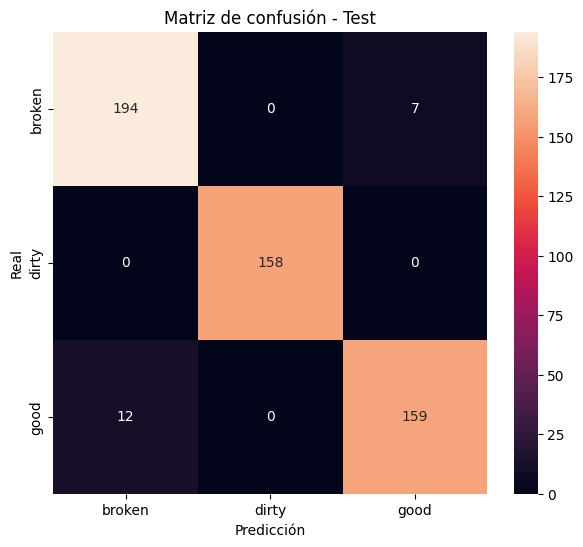

In [31]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Test")
plt.show()

In [32]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

      broken     0.9417    0.9652    0.9533       201
       dirty     1.0000    1.0000    1.0000       158
        good     0.9578    0.9298    0.9436       171

    accuracy                         0.9642       530
   macro avg     0.9665    0.9650    0.9656       530
weighted avg     0.9643    0.9642    0.9641       530



In [33]:
errores = []

for images, labels in test_ds:

    predictions = best_model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    probabilities = np.max(
        predictions,
        axis=1
    )

    for i in range(len(labels)):

        real = int(labels[i])
        pred = int(predicted_classes[i])

        if real != pred:

            errores.append({
                "imagen": images[i].numpy().astype("uint8"),
                "real": class_names[real],
                "prediccion": class_names[pred],
                "confianza": float(probabilities[i])
            })

print(f"Total de errores: {len(errores)}")

Total de errores: 19


In [34]:
from collections import Counter

confusiones = Counter()

for error in errores:

    confusiones[
        (error["real"], error["prediccion"])
    ] += 1

print("Confusiones:")
for par, cantidad in confusiones.items():
    print(f"{par[0]} → {par[1]}: {cantidad}")

Confusiones:
broken → good: 7
good → broken: 12


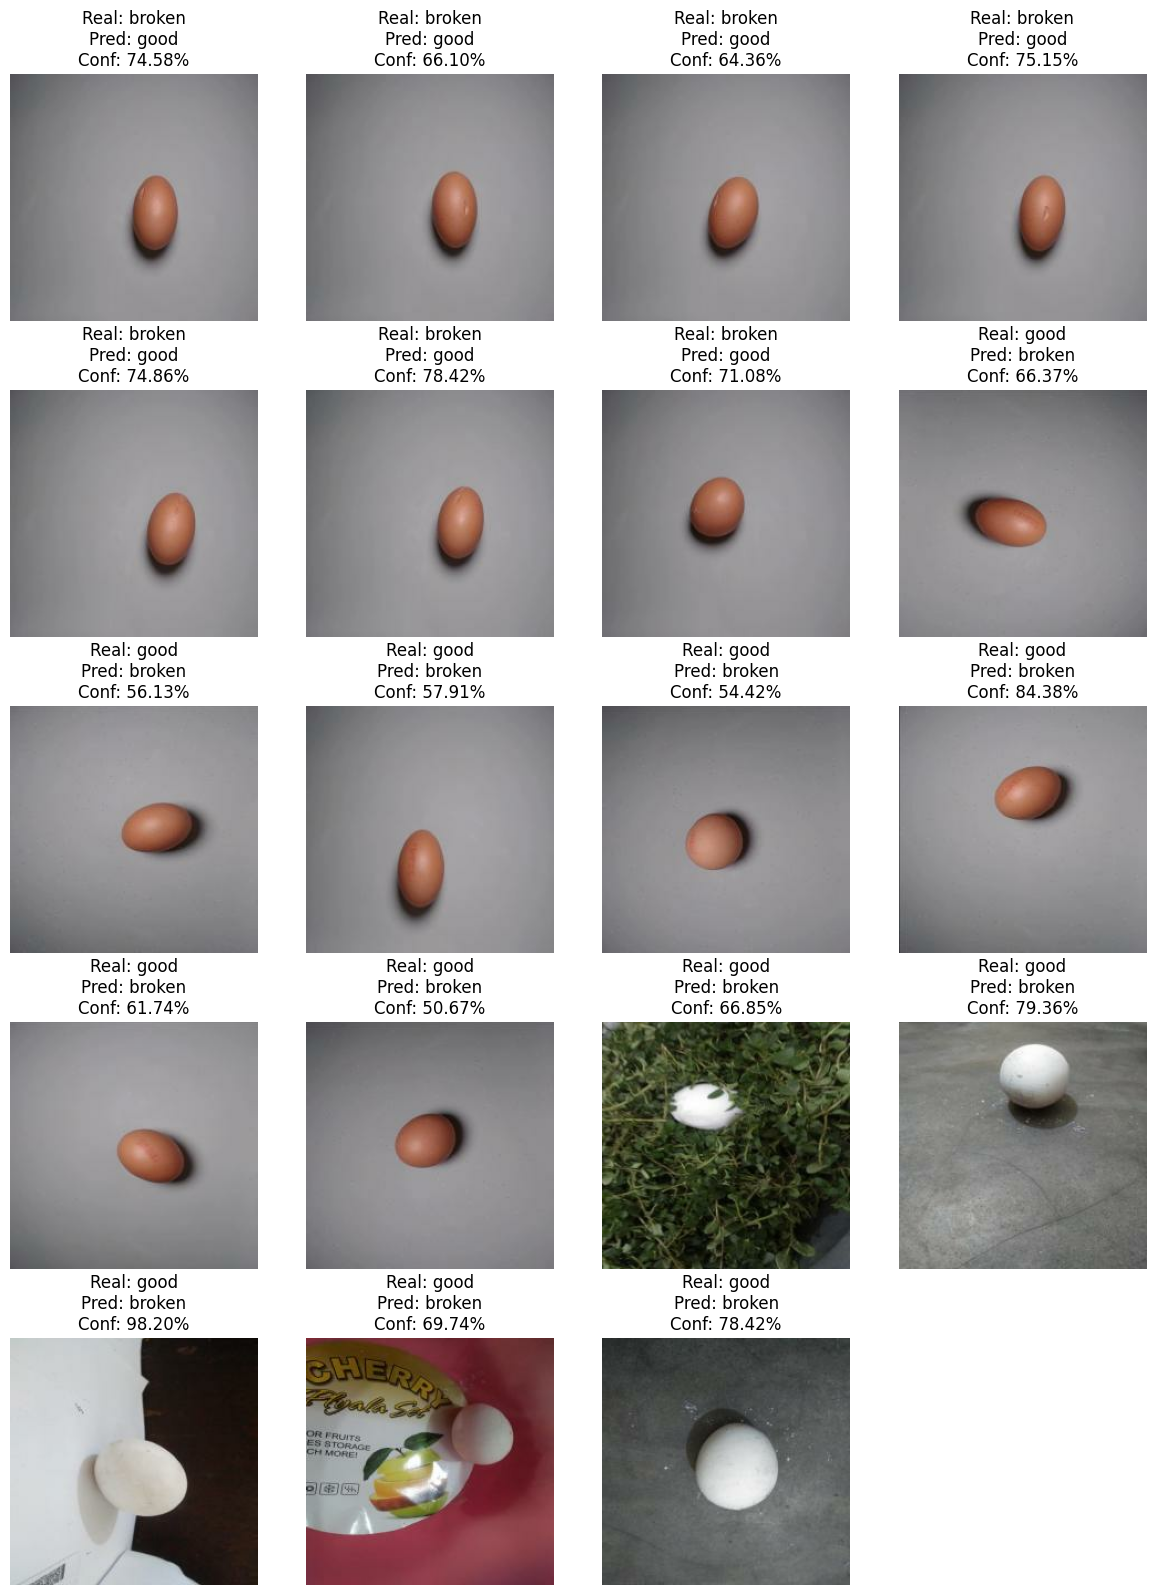

In [35]:
plt.figure(figsize=(12, 16))

for i, error in enumerate(errores):

    ax = plt.subplot(5, 4, i + 1)

    plt.imshow(error["imagen"])

    plt.title(
        f"Real: {error['real']}\n"
        f"Pred: {error['prediccion']}\n"
        f"Conf: {error['confianza']:.2%}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Checkpoint 

In [38]:
from google.colab import drive
drive.mount('/content/drive')
# Guardar el modelo en Miunidad/CLase_ciencia_datos_visual_colab
model.save('/content/drive/MyDrive/CLase_ciencia_datos_visual_colab/best_egg_model.keras')


Mounted at /content/drive


In [41]:
print("Sesion no te cierres")

Sesion no te cierres
